In [3]:
# !pip install bnlearn

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.figure_factory as ff
import plotly.offline as py
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


from graphviz import Digraph
import matplotlib.colors as mcolors

import bnlearn as bn


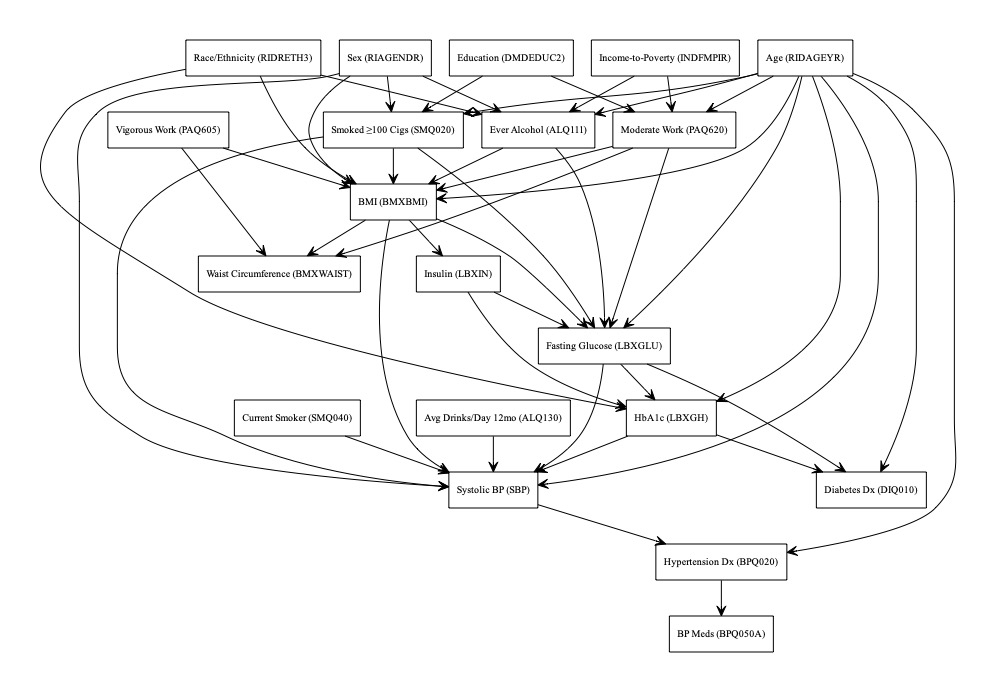

In [5]:
from IPython.display import Image
Image("NHANES_BN_Expanded.jpg")

# Load dataset

In [6]:
demo = pd.read_sas("./dataset/P_DEMO.xpt")
bmx = pd.read_sas("./dataset/P_BMX.xpt")
alq = pd.read_sas("./dataset/P_ALQ.xpt")
bpq = pd.read_sas("./dataset/P_BPQ.xpt")
diq = pd.read_sas("./dataset/P_DIQ.xpt")
smq = pd.read_sas("./dataset/P_SMQ.xpt")
paq = pd.read_sas("./dataset/P_PAQ.xpt")
glu = pd.read_sas("./dataset/P_GLU.xpt")
ins = pd.read_sas("./dataset/P_INS.xpt")
ghb = pd.read_sas("./dataset/P_GHB.xpt")

demo_cols = ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "DMDEDUC2", "INDFMPIR"]
bmx_cols = ["SEQN", "BMXBMI", "BMXWAIST"]
alq_cols = ["SEQN", "ALQ111", "ALQ130"]
bpq_cols = ["SEQN", "BPQ020", "BPQ050A"]
diq_cols = ["SEQN", "DIQ010"]
smq_cols = ["SEQN", "SMQ020", "SMQ040"]
paq_cols = ["SEQN", "PAQ605", "PAQ620"]
glu_cols = ["SEQN", "LBXGLU"]
ins_cols = ["SEQN", "LBXIN"]
ghb_cols = ["SEQN", "LBXGH"]

demo_sel = demo[demo_cols]
bmx_sel = bmx[bmx_cols]
alq_sel = alq[alq_cols]
bpq_sel = bpq[bpq_cols]
diq_sel = diq[diq_cols]
smq_sel = smq[smq_cols]
paq_sel = paq[paq_cols]
glu_sel = glu[glu_cols]
ins_sel = ins[ins_cols]
ghb_sel = ghb[ghb_cols]

merged = demo_sel.merge(bmx_sel, on="SEQN", how="inner")
merged = merged.merge(alq_sel, on="SEQN", how="inner")
merged = merged.merge(bpq_sel, on="SEQN", how="inner")
merged = merged.merge(diq_sel, on="SEQN", how="inner")
merged = merged.merge(smq_sel, on="SEQN", how="inner")
merged = merged.merge(paq_sel, on="SEQN", how="inner")
merged = merged.merge(glu_sel, on="SEQN", how="inner")
merged = merged.merge(ins_sel, on="SEQN", how="inner")
merged = merged.merge(ghb_sel, on="SEQN", how="inner")
data = merged

def determine_diabetes_risk(row):
    # Missing case: all diabetes-related variables missing
    if (
        pd.isna(row['LBXGLU']) and
        pd.isna(row['LBXIN']) and
        pd.isna(row['LBXGH']) and
        pd.isna(row['DIQ010'])
    ):
        return 2  # Missing Data

    # Diabetes risk case
    if (
        (pd.notna(row['LBXGLU']) and row['LBXGLU'] >= 126) or
        (pd.notna(row['LBXIN']) and row['LBXIN'] >= 15) or
        (pd.notna(row['LBXGH']) and row['LBXGH'] >= 6.5) or
        (pd.notna(row['DIQ010']) and row['DIQ010'] == 1)
    ):
        return 1  # Diabetes Risk

    # Otherwise no risk
    return 0


# Apply function
data['diabetes_risk'] = data.apply(determine_diabetes_risk, axis=1)

# Convert to category and rename levels properly
data['diabetes_risk'] = data['diabetes_risk'].astype('category')
data['diabetes_risk'] = data['diabetes_risk'].cat.rename_categories({
    0: 'No Diabetes Risk',
    1: 'Diabetes Risk',
    2: 'Missing Data'
})

data.head()

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,BMXBMI,BMXWAIST,ALQ111,ALQ130,...,BPQ050A,DIQ010,SMQ020,SMQ040,PAQ605,PAQ620,LBXGLU,LBXIN,LBXGH,diabetes_risk
0,109271.0,49.0,1.0,3.0,2.0,NaN,29.7,120.4,1.0,NaN,...,NaN,2.0,1.0,1.0,2.0,1.0,103.0,16.96,5.6,Diabetes Risk
1,109274.0,68.0,1.0,7.0,4.0,1.20,30.2,109.6,1.0,2.0,...,1.0,1.0,2.0,NaN,1.0,1.0,154.0,13.52,5.7,Diabetes Risk
2,109282.0,76.0,1.0,3.0,5.0,3.61,26.6,NaN,1.0,NaN,...,1.0,2.0,1.0,3.0,2.0,2.0,95.0,7.49,5.5,No Diabetes Risk
3,109286.0,33.0,2.0,6.0,5.0,1.36,28.9,NaN,NaN,NaN,...,NaN,2.0,2.0,NaN,2.0,2.0,92.0,16.46,5.7,Diabetes Risk
4,109290.0,68.0,2.0,4.0,5.0,5.00,28.1,92.0,1.0,NaN,...,1.0,1.0,2.0,NaN,2.0,1.0,106.0,20.25,8.4,Diabetes Risk


# List of attributes
* **RIDAGEYR**: Age in years, at the time of the screening interview
* **RIAGENDR**: Gender of the participant
* **RIDRETH3**: Recode of reported race and Hispanic origin information, with Non-Hispanic Asian Category
* **DMDEDUC2**: Education level - Adults 20+
* **INDFMPIR**: Ratio of family income to poverty
* **BMXBMI**: Body Mass Index (kg/m**2)
* **BMXWAIST**: Waist Circumference (cm)
* **ALQ111**: Ever had a drink of any kind of alcohol
* **ALQ130**: Avg # alcoholic drinks/day - past 12 mos
* **BPQ020**: Ever told you had high blood pressure
* **BPQ050A**: Now taking prescribed medicine for HBP
* **DIQ010**: Doctor told you have diabetes
* **SMQ020**: Smoked at least 100 cigarettes in life
* **SMQ040**: {Do you/Does SP} now smoke cigarettes?
* **PAQ605**: Vigorous work activity
* **PAQ620**: Moderate work activity
* ***LBXGLU***: Fasting Glucose (mg/dL)
* **LBXIN**: Insulin (μU/mL)
* **LBXGH**: HbA1c (Glycohemoglobin (%))

In [7]:
labels = {
    # --- Demographics ---
    "SEQN": "Sequence Number",
    "RIDAGEYR": "Age (years)",
    "RIAGENDR": "Gender (1=Male, 2=Female)",
    "RIDRETH3": "Race/Ethnicity",
    "DMDEDUC2": "Education level (Adults 20+)",
    "INDFMPIR": "Income-to-poverty ratio",

    # --- Behaviors ---
    "SMQ020": "Smoked ≥100 cigarettes in life (1=Yes, 2=No)",
    "SMQ040": "Current smoking status",
    "ALQ111": "Ever had a drink of alcohol (1=Yes, 2=No)",
    "ALQ130": "Average # of alcoholic drinks/day (past 12 months)",
    "PAQ605": "Vigorous work activity (1=Yes, 2=No)",
    "PAQ620": "Moderate work activity (1=Yes, 2=No)",

    # --- Biomarkers ---
    "BMXBMI": "Body Mass Index (kg/m²)",
    "BMXWAIST": "Waist circumference (cm)",
    "SBP": "Average Systolic Blood Pressure (mmHg)",
    "LBXGLU": "Fasting Glucose (mg/dL)",
    "LBXIN": "Insulin (μU/mL)",
    "LBXGH": "Glycohemoglobin (HbA1c, %)",

    # --- Outcomes ---
    "BPQ020": "Ever told had high blood pressure",
    "BPQ050A": "Taking prescribed medicine for hypertension",
    "DIQ010": "Doctor told you have diabetes",

    # --- Derived ---
    "diabetes_risk": "Derived diabetes risk (0=No risk, 1=Risk, 2=Missing)"
}

continuous_vars = ['RIDAGEYR', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'ALQ130', 'LBXGLU', 'LBXIN', 'LBXGH']
categorical_vars = ['RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'ALQ111', 'BPQ020', 'BPQ050A', 'DIQ010', 'SMQ020', 'SMQ040', 'PAQ605', 'PAQ620', 'diabetes_risk']
variables = continuous_vars + categorical_vars

# Handling Missing Values

In [8]:
# Dictionary of "special codes" that mean missing for each var
missing_code_map = {
    # education: 7 = Refused, 9 = Don't know
    "DMDEDUC2": [7, 9],

    # Alcohol in past 12 months: 7 = Refused, 9 = Don't know
    "ALQ111": [7, 9],

    # Number of drinks per day: 777 = Missing, 999 = Not applicable
    "ALQ130": [777, 999],

    # Blood pressure told high: 7 = Refused, 9 = Don't know
    "BPQ020": [7, 9],

    # Told to take BP medication: 7 = Refused, 9 = Don't know
    "BPQ050A": [7, 9],

    # Doctor diagnosed diabetes: 7 = Refused, 9 = Don't know
    "DIQ010": [7, 9],

    # Smoking: 7 = Refused, 9 = Don't know
    "SMQ020": [7, 9],
    "SMQ040": [7, 9],

    # Physical activity: 7 = Refused, 9 = Don't know
    "PAQ605": [7, 9],
    "PAQ620": [7, 9],
}

### Testing Whether ‘Refused’ Responses Are Associated With Diabetes Risk
NHANES uses code 7 (“Refused”) to indicate that a participant chose not to answer a question.
Because refusal may happen for sensitive topics (e.g., alcohol use, smoking, medical history), we hypothesized that:

> Refused responses (code 7) may be associated with diabetes risk, meaning individuals at higher or lower risk might be more likely to decline answering certain health- or lifestyle-related questions.

If this hypothesis is true, then “Refused” responses would behave like Missing Not At Random (MNAR), and the missingness itself could contain information.

To avoid introducing bias into our Bayesian Network, we need to test:
- Is “Refused” (code 7) statistically associated with diabetes_risk?
- If yes, ignoring refusal could hide meaningful patterns.
- If no, then refusal can be safely treated as Missing At Random (MAR) and imputed without creating a missingness indicator.

In [9]:
def test_refused(df, var, outcome="diabetes_risk"):
    """
    Minimal test: Does code 7 ('Refused') for `var` correlate with diabetes_risk?
    Prints only p-value + conclusion.
    """
    sub = df[[var, outcome]].dropna()

    # refused = 1 if code 7
    sub["refused"] = (sub[var] == 7).astype(int)

    # Crosstab for chi-square
    ctab = pd.crosstab(sub["refused"], sub[outcome])

    print(f"\n=== {var} ===")

    # Not enough refused cases to test
    if ctab.shape[0] < 2 or ctab.shape[1] < 2:
        print("Not enough refused cases → cannot test.")
        return

    # Chi-square test
    chi2, p, _, _ = stats.chi2_contingency(ctab)
    print(f"p-value: {p:.4f}")

    # Conclusion
    if p < 0.05:
        print("Conclusion: Refused (7) IS associated with diabetes risk.")
    else:
        print("Conclusion: No evidence that Refused (7) is associated with diabetes risk.")


# ----- Run for all variables using code 7 -----
refused_vars = ["ALQ111", "ALQ130", "BPQ020", "BPQ050A",
                "DIQ010", "SMQ020", "SMQ040", "PAQ605", "PAQ620"]

for v in refused_vars:
    if v in data.columns:
        test_refused(data, var=v)


=== ALQ111 ===
Not enough refused cases → cannot test.

=== ALQ130 ===
p-value: 0.9423
Conclusion: No evidence that Refused (7) is associated with diabetes risk.

=== BPQ020 ===
Not enough refused cases → cannot test.

=== BPQ050A ===
Not enough refused cases → cannot test.

=== DIQ010 ===
Not enough refused cases → cannot test.

=== SMQ020 ===
p-value: 0.8129
Conclusion: No evidence that Refused (7) is associated with diabetes risk.

=== SMQ040 ===
Not enough refused cases → cannot test.

=== PAQ605 ===
p-value: 1.0000
Conclusion: No evidence that Refused (7) is associated with diabetes risk.

=== PAQ620 ===
Not enough refused cases → cannot test.


### Conclusion about ‘Refused’ Responses Associated With Diabetes Risk
Across all variables where NHANES uses code 7 (“Refused”), the chi-square tests showed:
- Either not enough refused cases to perform a meaningful test
- Or very large p-values (p ≈ 0.81 – 1.00)

This means that there is no statistical evidence that refusal (code 7) is associated with diabetes_risk. In other words:
- Participants who refused to answer a question did not differ in diabetes risk compared with participants who answered.
- Refusal did not show a pattern that would indicate Missing Not At Random (MNAR) in this dataset.

**Therefore:**

We treat code 7 (“Refused”) as Missing At Random (MAR)
- Recode as NaN
- Impute normally
- Do NOT include missingness indicators for “Refused”.

## Impute missing values

In [10]:
# Work on a copy for the BN
data_bn = data.copy()

for col, codes in missing_code_map.items():
    if col in data_bn.columns:
        data_bn[col] = data_bn[col].replace(codes, np.nan)

# Impute continuous variables with median
for col in continuous_vars:
    if col in data_bn.columns:
        median_val = data_bn[col].median(skipna=True)
        data_bn[col] = data_bn[col].fillna(median_val)

# Impute categorical variables with "Missing" category
for col in categorical_vars:
    if col in data_bn.columns:
        data_bn[col] = data_bn[col].astype("category")
        if "Missing" not in data_bn[col].cat.categories:
            data_bn[col] = data_bn[col].cat.add_categories(["Missing"])
        data_bn[col] = data_bn[col].fillna("Missing")

# Discretization of Continuous Variables for BN
Age (RIDAGEYR)
- 18–29: teen_young
- 30–44: adult
- 45–59: middle
- 60–74: older
- 75+: elderly

Income to Poverty Ratio (INDFMPIR)
- <1.0: poor
- 1.0–2.0: low_income
- 2.0–4.0: mid_income
- 4.0: high_income

BMI (BMXBMI) — CDC Categories
- <18.5: underweight
- 18.5–24.9: normal
- 25–29.9: overweight
- ≥30: obese

Waist Circumference (BMXWAIST) — NIH Risk Thresholds
- <80 cm (31.5 in): small
- 80–88 cm (31.5–35 in): medium
- 88–102 cm (35–40 in): high
- 102 cm (40 in): very_high

Alcohol Intake (ALQ130)
- 0 drinks/day: none
- 0.1–1: light
- 1–2: moderate
- ≥3: heavy

Fasting Glucose (LBXGLU) — ADA
- <100: normal
- 100–125: prediabetic
- ≥126: diabetic

HbA1c (LBXGH) — ADA
- <5.7%: normal
- 5.7–6.4%: prediabetic
- ≥6.5%: diabetic

Fasting Insulin (LBXIN):
- <5 µU/mL: low
- 5–15: normal
- 15: high

In [11]:
df = data_bn.copy()

# Age
df["RIDAGEYR_disc"] = pd.cut(
    df["RIDAGEYR"],
    bins=[0, 29, 44, 59, 74, 150],
    labels=["teen_young", "adult", "middle", "older", "elderly"]
)

# Poverty Ratio
df["INDFMPIR_disc"] = pd.cut(
    df["INDFMPIR"],
    bins=[-0.1, 1, 2, 4, 20],
    labels=["poor", "low_income", "mid_income", "high_income"]
)

# BMI
df["BMXBMI_disc"] = pd.cut(
    df["BMXBMI"],
    bins=[0, 18.5, 25, 30, 200],
    labels=["underweight", "normal", "overweight", "obese"],
    right=False
)

# Waist Circumference (cm)
df["BMXWAIST_disc"] = pd.cut(
    df["BMXWAIST"],
    bins=[0, 80, 88, 102, 300],
    labels=["small", "medium", "high", "very_high"]
)

# Alcohol Drinks per Day
df["ALQ130_disc"] = pd.cut(
    df["ALQ130"],
    bins=[-0.1, 0.5, 1, 2, 50],
    labels=["none", "light", "moderate", "heavy"]
)

# Fasting Glucose
df["LBXGLU_disc"] = pd.cut(
    df["LBXGLU"],
    bins=[0, 100, 125, 500],
    labels=["normal", "prediabetic", "diabetic"]
)

# Fasting Insulin
df["LBXIN_disc"] = pd.cut(
    df["LBXIN"],
    bins=[0, 5, 15, 200],
    labels=["low", "normal", "high"]
)

# HbA1c
df["LBXGH_disc"] = pd.cut(
    df["LBXGH"],
    bins=[0, 5.7, 6.4, 20],
    labels=["normal", "prediabetic", "diabetic"]
)

# List of discretized variables
discrete_vars = [
    "RIDAGEYR_disc", "INDFMPIR_disc", "BMXBMI_disc", "BMXWAIST_disc",
    "ALQ130_disc", "LBXGLU_disc", "LBXIN_disc", "LBXGH_disc"
]

# Final list of categorical variables for BN
vars_bn = categorical_vars + discrete_vars

# Datframe for constructing the BN
df_bn = df[vars_bn].copy()

# Convert all variables to string type (categorical)
for col in df_bn.columns:
    df_bn[col] = df_bn[col].astype(str)

# Split into Train/Test

In [12]:
df_train, df_test = train_test_split(df_bn, test_size=0.3, random_state=123)

# 7. Structure learning

## 7.1 Domain DAG

In [13]:
# The directed edges defined by domain knowledge
edges_domain = [
    # Demographics → behaviors
    # ("RIDAGEYR_disc", "SMQ020"),
    ("RIAGENDR",       "SMQ020"),
    # ("RIDRETH3",       "SMQ020"),

    ("RIDAGEYR_disc", "ALQ111"),
    ("RIAGENDR",       "ALQ111"),
    ("INDFMPIR_disc",  "ALQ111"),

    ("RIDAGEYR_disc", "PAQ605"),
    ("RIDAGEYR_disc", "PAQ620"),
    ("DMDEDUC2",       "PAQ605"),
    ("DMDEDUC2",       "PAQ620"),
    ("INDFMPIR_disc",  "PAQ605"),
    ("INDFMPIR_disc",  "PAQ620"),

    # Ever smoked → current smoker
    ("SMQ020", "SMQ040"),

    # Ever alcohol → avg drinks/day
    ("ALQ111", "ALQ130_disc"),

    # Demographics + behaviors → BMI
    ("RIDAGEYR_disc", "BMXBMI_disc"),
    ("RIAGENDR",       "BMXBMI_disc"),
    ("RIDRETH3",       "BMXBMI_disc"),
    # ("DMDEDUC2",       "BMXBMI_disc"),
    # ("INDFMPIR_disc",  "BMXBMI_disc"),
    ("SMQ020",         "BMXBMI_disc"),
    ("ALQ111",         "BMXBMI_disc"),
    ("PAQ605",         "BMXBMI_disc"),
    ("PAQ620",         "BMXBMI_disc"),

    # BMI → waist, insulin, glucose
    ("BMXBMI_disc", "BMXWAIST_disc"),
    ("BMXBMI_disc", "LBXIN_disc"),
    ("BMXBMI_disc", "LBXGLU_disc"),

    # Waist & insulin → glucose
    ("BMXWAIST_disc", "LBXGLU_disc"),
    ("LBXIN_disc",    "LBXGLU_disc"),

    # Glucose → HbA1c & diabetes diagnosis
    ("LBXGLU_disc", "LBXGH_disc"),
    ("LBXGLU_disc", "DIQ010"),
    ("LBXGH_disc",  "DIQ010"),

    # Glucose/BMI/Age → hypertension dx
    ("LBXGLU_disc",   "BPQ020"),
    ("BMXBMI_disc",   "BPQ020"),
    ("RIDAGEYR_disc", "BPQ020"),

    # Hypertension dx → BP meds
    ("BPQ020", "BPQ050A"),

    # Final diabetes risk node
    ("DIQ010",       "diabetes_risk"),
    ("LBXGLU_disc",  "diabetes_risk"),
    ("LBXGH_disc",   "diabetes_risk"),
    ("BMXBMI_disc",  "diabetes_risk"),
    ("RIDAGEYR_disc","diabetes_risk")
]

In [14]:
# Define white list and black list of edges
white_list = edges_domain

nodes = vars_bn

demographics = ["RIDAGEYR_disc", "RIAGENDR", "RIDRETH3", "DMDEDUC2", "INDFMPIR_disc"]
outcomes     = ["diabetes_risk", "DIQ010", "BPQ020", "BPQ050A"]

black_list = []

# Forbid edges INTO demographics (they should be roots)
for demo in demographics:
    for other in nodes:
        if other != demo:
            black_list.append((other, demo))

# Forbid edges OUT OF outcome nodes (they should be leaves)
for out in outcomes:
    for other in nodes:
        if other != out:
            black_list.append((out, other))

In [ ]:
model_domain = bn.make_DAG(white_list, methodtype="bayes", verbose=2)
# bn.plot(model_domain)   # bn visualization

## 7.2 Hybrid DAG

In [16]:
model_hybrid = bn.structure_learning.fit(
    df_bn,                    # use full data for stability
    methodtype='hc',          # hill-climbing search
    scoretype='bic',          # BIC scoring
    black_list=black_list,    # forbidden directions
    fixed_edges=edges_domain, # edges that MUST be kept
    bw_list_method='enforce', # required when using black_list/fixed_edges
    verbose=0
)
# bn.plot(model_hybrid)

# 8. Structure Evaluation

## 8.1 Compare structure scores

In [43]:
# Higher = better.
model_domain_fitted = bn.parameter_learning.fit(model_domain, df_bn, verbose=0)
print("Domain structure score:", model_domain_fitted['structure_scores'])
print("Hybrid structure score:", model_hybrid['structure_scores'])

Domain structure score: {'k2': np.float64(-67377.43169763719), 'bic': np.float64(-138913.1461552681), 'bdeu': np.float64(-78905.3618590535), 'bds': np.float64(-100018.31113944785)}
Hybrid structure score: {'k2': np.float64(-65773.04098916368), 'bic': np.float64(-137529.32155448492), 'bdeu': np.float64(-77236.0659208079), 'bds': np.float64(-98363.39745366828)}


**Conclusion**: All four scoring metrics (K2, BIC, BDeu, and BDs) consistently indicate that the hybrid structure provides a better fit to the NHANES data compared to the pure domain knowledge structure. That means:
- The hybrid model explains the relationships in the data better
- It balances complexity and goodness-of-fit better
- The learned additional edges improve the structure
- But the structure still respects causal and domain constraints (because you enforced them)


## 8.2 Bootstrap stability

In [52]:
import bnlearn as bn
from collections import Counter

def get_stable_new_edges(
    df_bn,
    edges_domain,
    black_list,
    n_boot=20,
    stability_threshold=10,  # keep edges appearing >= 10 times
    methodtype='hc',
    scoretype='bic'
):
    """
    Bootstrap structure learning and return only NEW edges
    that appear in >= stability_threshold runs.
    """
    all_edges = []

    for b in range(n_boot):
        df_boot = df_bn.sample(frac=1.0, replace=True, random_state=100 + b)

        model_boot = bn.structure_learning.fit(
            df_boot,
            methodtype=methodtype,
            scoretype=scoretype,
            black_list=black_list,
            fixed_edges=edges_domain,
            bw_list_method='enforce',
            verbose=0
        )

        # only consider NEW edges (not fixed domain edges)
        for edge in model_boot["model_edges"]:
            if edge not in edges_domain:
                all_edges.append(edge)

    # count how many times each NEW edge appears
    counts = Counter(all_edges)

    # keep only edges ≥ threshold
    stable_new_edges = [edge for edge, c in counts.items() if c >= stability_threshold]

    # Print summary
    print(f"\n=== Stable NEW edges (>= {stability_threshold}/{n_boot} runs) ===")
    for edge, c in counts.items():
        if c >= stability_threshold:
            print(f"{edge[0]} -> {edge[1]} : {c}/{n_boot} runs")
    
    print(f"\nDropped low-stability edges (< {stability_threshold} runs).")
    print(f"\n=== Dropped edges (< {stability_threshold}/{n_boot} runs) ===")
    for edge, c in counts.items():
        if c < stability_threshold:
            print(f"{edge[0]} -> {edge[1]} : {c}/{n_boot} runs")

    return stable_new_edges

stable_new_edges = get_stable_new_edges(
    df_bn,
    edges_domain,
    black_list,
    n_boot=20,
    stability_threshold=10
)


=== Stable NEW edges (>= 10/20 runs) ===
RIAGENDR -> BMXWAIST_disc : 14/20 runs
DMDEDUC2 -> RIDAGEYR_disc : 20/20 runs
DMDEDUC2 -> RIDRETH3 : 16/20 runs
ALQ111 -> SMQ020 : 11/20 runs
PAQ605 -> RIAGENDR : 12/20 runs
RIDAGEYR_disc -> BPQ050A : 20/20 runs
RIDAGEYR_disc -> LBXGH_disc : 18/20 runs
DMDEDUC2 -> INDFMPIR_disc : 17/20 runs
RIDAGEYR_disc -> ALQ130_disc : 13/20 runs

Dropped low-stability edges (< 10 runs).

=== Dropped edges (< 10/20 runs) ===
RIAGENDR -> ALQ130_disc : 6/20 runs
INDFMPIR_disc -> DMDEDUC2 : 3/20 runs
RIDRETH3 -> DMDEDUC2 : 4/20 runs
RIDAGEYR_disc -> BMXWAIST_disc : 6/20 runs
BPQ050A -> LBXGH_disc : 2/20 runs
SMQ040 -> DMDEDUC2 : 6/20 runs
SMQ020 -> DMDEDUC2 : 2/20 runs
DMDEDUC2 -> SMQ020 : 2/20 runs
SMQ020 -> ALQ130_disc : 1/20 runs
RIDAGEYR_disc -> SMQ040 : 1/20 runs


**Bootstrap Stability Analysis Conclusion:**

We evaluated the robustness of the data-driven edges using 20 bootstrap replications, excluding domain edges because they were fixed during structure learning. 
- Several new edges demonstrated high stability (≥ 15/20 runs), including DMDEDUC2 → RIDAGEYR_disc, RIDAGEYR_disc → BPQ050A, and RIDAGEYR_disc → LBXGH_disc, indicating strong empirical support.
- Moderate-stability edges (10–14 runs), such as RIAGENDR → BMXWAIST_disc and ALQ111 → SMQ020, were retained as weaker but plausible associations. 
- Low-stability edges (< 10 runs) were removed because they likely reflect sampling noise rather than genuine structural relationships.

The final hybrid Bayesian Network therefore includes only new edges that are both empirically stable and interpretable, improving robustness and clarity of the resulting model.

## 8.3 Medical interpretability check

In [19]:
# Remove weird or impossible edges if needed.

## 8.4 Choose the final structure

In [58]:
final_edges = list(set(edges_domain) | set(stable_new_edges))
model_hybrid_final = bn.make_DAG(final_edges)

print("Total final edges:", len(final_edges))
for u, v in sorted(final_edges):
    print(f"{u} -> {v}")

[bnlearn]> Auto generate placeholders for the CPTs.
[bnlearn] >CPT for BMXBMI_disc:
+----------------+------------------+-----+------------------+
| SMQ020         | SMQ020(0)        | ... | SMQ020(1)        |
+----------------+------------------+-----+------------------+
| PAQ620         | PAQ620(0)        | ... | PAQ620(1)        |
+----------------+------------------+-----+------------------+
| PAQ605         | PAQ605(0)        | ... | PAQ605(1)        |
+----------------+------------------+-----+------------------+
| RIAGENDR       | RIAGENDR(0)      | ... | RIAGENDR(1)      |
+----------------+------------------+-----+------------------+
| RIDAGEYR_disc  | RIDAGEYR_disc(0) | ... | RIDAGEYR_disc(1) |
+----------------+------------------+-----+------------------+
| ALQ111         | ALQ111(0)        | ... | ALQ111(1)        |
+----------------+------------------+-----+------------------+
| RIDRETH3       | RIDRETH3(0)      | ... | RIDRETH3(1)      |
+----------------+----------------

# 9. Parameter learning

In [59]:
model_fitted = bn.parameter_learning.fit(
    model_hybrid_final,
    df_train,
    verbose=0
)
# bn.print_CPD(model_fitted)

# 10. Parameter Evaluation

### How `diabetes_risk` changes with key variables

In this step, we evaluate whether the learned parameters (CPTs) behave in a meaningful
way. Instead of reading the full conditional probability tables, we focus on how the model changes
the probability of `diabetes_risk` when we vary important clinical variables:

- Fasting glucose (`LBXGLU_disc`)
- HbA1c (`LBXGH_disc`)
- BMI category (`BMXBMI_disc`)

For each of these variables, we compute:

$P(\text{diabetes\_risk} \mid X = \text{state})$
using Bayesian Network inference.

We expect:
- Higher glucose categories (normal → prediabetic → diabetic) to increase diabetes risk.
- Higher HbA1c categories to increase diabetes risk.
- Higher BMI categories (normal → overweight → obese) to increase diabetes risk.

If the probabilities follow these monotonic trends, it provides evidence that the learned CPTs are
clinically reasonable and that parameter learning succeeded.

In [85]:
def summarize_risk_given(model_dict, evidence_col, evidence_states, target="diabetes_risk"):
    """
    For each state in evidence_states, compute P(target | evidence_col = state)
    using BN inference, and return a DataFrame.
    """
    results = {}

    for state in evidence_states:
        q = bn.inference.fit(
            model_dict,
            variables=[target],
            evidence={evidence_col: state},
            verbose=0
        )
        s = q.df.set_index(target)["p"]
        results[state] = s.to_dict()

    return pd.DataFrame(results)


# 1) Diabetes risk by glucose category
print("\n=== P(diabetes_risk | LBXGLU_disc) ===")
df_glu = summarize_risk_given(
    model_fitted,               
    evidence_col="LBXGLU_disc",
    evidence_states=["normal", "prediabetic", "diabetic"] 
)
print(df_glu)


# 2) Diabetes risk by HbA1c category
print("\n=== P(diabetes_risk | LBXGH_disc) ===")
df_hba1c = summarize_risk_given(
    model_fitted,
    evidence_col="LBXGH_disc",
    evidence_states=["normal", "prediabetic", "diabetic"]
)
print(df_hba1c)


# 3) Diabetes risk by BMI category
print("\n=== P(diabetes_risk | BMXBMI_disc) ===")
df_bmi = summarize_risk_given(
    model_fitted,
    evidence_col="BMXBMI_disc",
    evidence_states=["underweight", "normal", "overweight", "obese"]
)
print(df_bmi)


=== P(diabetes_risk | LBXGLU_disc) ===
                    normal  prediabetic  diabetic
Diabetes Risk     0.241462     0.367713  0.719206
No Diabetes Risk  0.758538     0.632287  0.280794

=== P(diabetes_risk | LBXGH_disc) ===
                    normal  prediabetic  diabetic
Diabetes Risk     0.248931     0.472627  0.717687
No Diabetes Risk  0.751069     0.527373  0.282313

=== P(diabetes_risk | BMXBMI_disc) ===
                  underweight    normal  overweight     obese
Diabetes Risk        0.353983  0.238674    0.345288  0.553871
No Diabetes Risk     0.646017  0.761326    0.654712  0.446129


**Conclusion:**
The conditional probability estimates from the final Bayesian Network behave in a clinically meaningful way. Diabetes risk increases consistently across worsening physiological categories:
- Glucose: 24% (normal) → 37% (prediabetic) → 72% (diabetic)
- HbA1c: 25% (normal) → 47% (prediabetic) → 72% (diabetic)
- BMI: 24% (normal) → 35% (overweight) → 55% (obese)

These monotonic trends align with established medical knowledge, demonstrating that the learned CPTs correctly capture the relationships between glucose, HbA1c, BMI, and diabetes risk. Overall, the parameter learning step produced coherent and clinically consistent probabilities, supporting the validity of the final BN model.

# Predictive Evaluation
Although a Bayesian Network can perform inference on any variable in the model, predictive evaluation is applied only to diabetes_risk because it is the final outcome of interest. All other variables (e.g., BMI, glucose, HbA1c, smoking) are input features or intermediate physiological states that users provide directly. These variables are not prediction targets, and evaluating accuracy on them would not be meaningful for our application. Therefore, predictive performance is measured solely for diabetes_risk, which reflects how well the model supports diabetes risk assessment.


In [72]:
def bn_accuracy_confusion(model_fitted, data, target="diabetes_risk"):
    y_true = []
    y_pred = []
    
    for _, row in data.iterrows():
        evidence = row.drop(target).to_dict()
        
        q = bn.inference.fit(
            model_fitted,
            variables=[target],
            evidence=evidence,
            verbose=0
        )
        
        pred = q.df.loc[q.df['p'].idxmax(), target]

        y_true.append(row[target])
        y_pred.append(pred)

    acc = sum([t==p for t,p in zip(y_true,y_pred)]) / len(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=sorted(set(y_true)))

    return acc, cm, sorted(set(y_true))

acc, cm, labels = bn_accuracy_confusion(model_fitted, df_test, target="diabetes_risk")
print(f"Test accuracy (diabetes_risk): {acc:.3f}")
print("Confusion Matrix:")
print(cm)


Test accuracy (diabetes_risk): 0.821
Confusion Matrix:
[[381 158]
 [ 80 713]]


**Conclusion:**

Using the finalized hybrid Bayesian Network, we evaluated predictive performance on the held-out test set. The model achieved 82.1\% accuracy in predicting diabetes risk on the held-out test set.

The confusion matrix shows strong performance overall, with relatively few false negatives (80) compared to true positives (713). This indicates that the model is effective at identifying individuals at higher diabetes risk, which is important for early screening. Overall, the BN provides a reliable predictive tool based on the available NHANES features.


# 13. Final Inference Examples

In [86]:
q = bn.inference.fit(
    model_fitted,
    variables=["diabetes_risk"],
    evidence={
        "BMXBMI_disc": "obese",
        "LBXGLU_disc": "prediabetic",
        "LBXGH_disc":  "prediabetic",
        "RIDAGEYR_disc": "older"
    },
    verbose=0
)
print(q.df)

      diabetes_risk         p
0     Diabetes Risk  0.699574
1  No Diabetes Risk  0.300426


In [ ]:
# TODO: More

# Print the final DAG

In [91]:
from graphviz import Digraph

# All nodes with labels
nodes = {
    "RIAGENDR": "Sex (RIAGENDR)",
    "RIDRETH3": "Race/Ethnicity (RIDRETH3)",
    "DMDEDUC2": "Education (DMDEDUC2)",
    "ALQ111": "Ever Alcohol (ALQ111)",
    "BPQ020": "Hypertension Dx (BPQ020)",
    "BPQ050A": "BP Meds (BPQ050A)",
    "DIQ010": "Diabetes Dx (DIQ010)",
    "SMQ020": "Smoked ≥100 Cigs (SMQ020)",
    "SMQ040": "Current Smoker (SMQ040)",
    "PAQ605": "Vigorous Work (PAQ605)",
    "PAQ620": "Moderate Work (PAQ620)",
    "diabetes_risk": "Diabetes Risk",
    "RIDAGEYR_disc": "Age (disc)",
    "INDFMPIR_disc": "Income/Poverty (disc)",
    "BMXBMI_disc": "BMI (disc)",
    "BMXWAIST_disc": "Waist Circ (disc)",
    "ALQ130_disc": "Avg Drinks/Day (disc)",
    "LBXGLU_disc": "Fasting Glucose (disc)",
    "LBXIN_disc": "Insulin (disc)",
    "LBXGH_disc": "HbA1c (disc)"
}

# Edges defined by domain knowledge
print("\n=== Domain edges ===")
print(edges_domain)

# Edges from hybrid model
model_edges = model_hybrid_final["model_edges"]

# Identify NEW edges added by the hybrid model
new_edges = [e for e in model_edges if e not in edges_domain]

# Create Graphviz Digraph
g = Digraph(
    comment="NHANES_Hybrid_BN",
    node_attr={'shape': 'box', 'fontsize': '10'},
    edge_attr={'arrowhead': 'vee', 'splines': 'line'},
)

# Add nodes
for code, label in nodes.items():
    g.node(code, label)

# Add domain edges
for u, v in edges_domain:
    g.edge(u, v, color="black")

# Add new edges from hybrid model
for u, v in new_edges:
    g.edge(u, v, color="blue")

# Render
g.render("NHANES_Hybrid_BN", view=True)


=== Domain edges ===
[('RIAGENDR', 'SMQ020'), ('RIDAGEYR_disc', 'ALQ111'), ('RIAGENDR', 'ALQ111'), ('INDFMPIR_disc', 'ALQ111'), ('RIDAGEYR_disc', 'PAQ605'), ('RIDAGEYR_disc', 'PAQ620'), ('DMDEDUC2', 'PAQ605'), ('DMDEDUC2', 'PAQ620'), ('INDFMPIR_disc', 'PAQ605'), ('INDFMPIR_disc', 'PAQ620'), ('SMQ020', 'SMQ040'), ('ALQ111', 'ALQ130_disc'), ('RIDAGEYR_disc', 'BMXBMI_disc'), ('RIAGENDR', 'BMXBMI_disc'), ('RIDRETH3', 'BMXBMI_disc'), ('SMQ020', 'BMXBMI_disc'), ('ALQ111', 'BMXBMI_disc'), ('PAQ605', 'BMXBMI_disc'), ('PAQ620', 'BMXBMI_disc'), ('BMXBMI_disc', 'BMXWAIST_disc'), ('BMXBMI_disc', 'LBXIN_disc'), ('BMXBMI_disc', 'LBXGLU_disc'), ('BMXWAIST_disc', 'LBXGLU_disc'), ('LBXIN_disc', 'LBXGLU_disc'), ('LBXGLU_disc', 'LBXGH_disc'), ('LBXGLU_disc', 'DIQ010'), ('LBXGH_disc', 'DIQ010'), ('LBXGLU_disc', 'BPQ020'), ('BMXBMI_disc', 'BPQ020'), ('RIDAGEYR_disc', 'BPQ020'), ('BPQ020', 'BPQ050A'), ('DIQ010', 'diabetes_risk'), ('LBXGLU_disc', 'diabetes_risk'), ('LBXGH_disc', 'diabetes_risk'), ('BMXBMI_d

'NHANES_Hybrid_BN.pdf'

In [95]:
# Visualize Domain DAG image by Graphviz Digraph
g_domain = Digraph(
    comment="NHANES_Domain_BN",
    node_attr={'shape': 'box', 'fontsize': '10'},
    edge_attr={'arrowhead': 'vee', 'splines': 'line'},
)
# Add nodes
for code, label in nodes.items():
    g_domain.node(code, label)
# Add domain edges
for u, v in edges_domain:
    g_domain.edge(u, v, color="black")
# Add new edges from hybrid model, make them invisible 
for u, v in new_edges:
    g_domain.edge(u, v, color="transparent")
# Render
g_domain.render("NHANES_Domain_BN", view=True)


'NHANES_Domain_BN.pdf'